In [160]:
import xgboostmodel as xg
from prepare_data import prepare_data
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np

In [161]:
import os

DATA_DIR = os.path.join("..", "data")
filepaths=[
            os.path.join(DATA_DIR, "O013257.npz"),
            os.path.join(DATA_DIR, "O013490.npz"),
            os.path.join(DATA_DIR, "O012791.npz"),
        ]

**Train, Validation, Test split per meeting 3/15/26**

In [162]:
train_images=["O013490"]
val_images=["O012791"]
test_images=["O013257"]

In [163]:
images = ['O013490', 'O013257', 'O012791']
encoded_dfs = []

for i in images: 
    encoded_dfs.append(pd.read_csv(os.path.join('..', 'data', f'{i}.csv')))

dfs = pd.concat(encoded_dfs, ignore_index=True)

In [164]:
train_df, val_df,test_df, unlabeled_df = prepare_data(
    filepaths=["../data/O012791.npz", "../data/O013257.npz", "../data/O013490.npz"],
    coord_cols=["y_coord", "x_coord"],
    image_col="image_id",
    label_col="label",
    train_images=["O013490"],
    val_images=["O012791"],
    test_images=["O013257"],
    labeled_only=True,
    map_label_to_binary=True,
    scaler_type = 'standard'  ,  # "standard", "robust", or None,
    remove_outliers = False,
    outlier_threshold = 3.0
)

Loading data from 3 files...
Merging engineered features...
Successfully merged engineered features from ../data/O013490.csv for image O013490.
After merging, O013490 has 115032 rows and 116 columns.
Successfully merged engineered features from ../data/O012791.csv for image O012791.
After merging, O012791 has 114973 rows and 116 columns.
Successfully merged engineered features from ../data/O013257.csv for image O013257.
After merging, O013257 has 115000 rows and 116 columns.
Finished merging engineered features. Train shape: (115032, 116), Val shape: (114973, 116), Test shape: (115000, 116)
Preparing data...


## An important thing to consider in tuning for XGboost is imbalanced data. 

In [165]:
train_df['label'].value_counts()

label
0    42830
1    39253
Name: count, dtype: int64

In [166]:
val_df['label'].value_counts()

label
0    33528
1    21244
Name: count, dtype: int64

In [167]:
test_df['label'].value_counts()

label
0    50358
1    20468
Name: count, dtype: int64

**On inspection of training, validation, and test dataframes, the data is relatively balanced for XGBoost needs.**

## Initial evaluation with ALL features using XGboost

In [168]:
features = train_df.columns.tolist()
remove = ['y_coord', 'x_coord', 'label', 'image_id']

for rem in remove: 
    features.remove(rem)

In [169]:
X_train = train_df[features].values
y_train = train_df['label'].values
X_val   = val_df[features].values
y_val   = val_df['label'].values
X_test  = test_df[features].values
y_test  = test_df['label'].values

In [170]:
MODEL_FILE = 'XG_classifier.joblib'
xg.xgboost_train(X_train, y_train, model_path=MODEL_FILE, random_state=42)

if os.path.exists(MODEL_FILE):
    import joblib
    clf = joblib.load(MODEL_FILE)
    
   
    results = xg.xgboost_evaluate(
        clf=clf,
        X_val=X_val, y_val=y_val, 
        X_test=X_test, y_test=y_test,
        train_df=train_df, val_df=val_df, test_df=test_df,
        FEATURE_COLS=features
    )



/scratch/users/evalynna.ong/conda/envs/env_214_test/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:30:34] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained and saved to XG_classifier.joblib

── Validation Metrics ──
              precision    recall  f1-score   support

   not cloud       0.75      0.97      0.85     33528
       cloud       0.92      0.49      0.64     21244

    accuracy                           0.78     54772
   macro avg       0.84      0.73      0.74     54772
weighted avg       0.82      0.78      0.77     54772


── Test Metrics ──
              precision    recall  f1-score   support

   not cloud       0.78      1.00      0.88     50358
       cloud       0.99      0.31      0.48     20468

    accuracy                           0.80     70826
   macro avg       0.89      0.66      0.68     70826
weighted avg       0.84      0.80      0.76     70826


Feature Importances:
     feature   importance
  NDAI_5_max 8.496186e-01
  NDAI_3_max 6.822449e-02
CORR_13_mean 3.090279e-02
 CORR_9_mean 7.978952e-03
   DF_13_max 4.398014e-03
NDAI_13_mean 3.997258e-03
   SD_5_mean 3.689764e-03
    SD_9_min 3.305180e

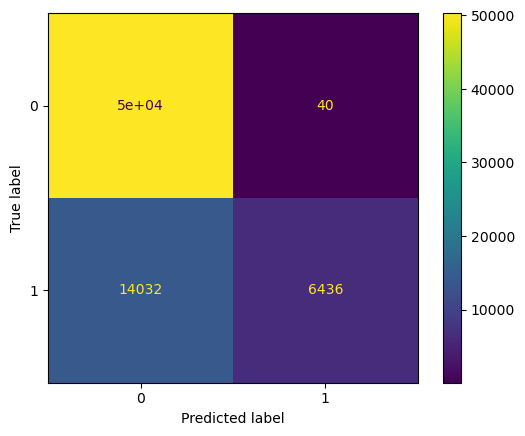


Cleaned up XG_classifier.joblib


In [171]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

if os.path.exists(MODEL_FILE): 
    os.remove(MODEL_FILE)
    print(f"\nCleaned up {MODEL_FILE}")

## Many of the engineered features are highly correlated
To avoid overfitting, the 25 features with highest feature importance are chosen

In [172]:
results['top_features']

['NDAI_5_max',
 'NDAI_3_max',
 'CORR_13_mean',
 'CORR_9_mean',
 'DF_13_max',
 'NDAI_13_mean',
 'SD_5_mean',
 'SD_9_min',
 'AF_9_mean',
 'NDAI_9_max',
 'AN_13_min',
 'NDAI_13_min',
 'SD_9_mean',
 'NDAI_5_mean',
 'AF_5_max',
 'ae3',
 'CF_13_mean',
 'CORR_5_min',
 'AN_9_min',
 'AN_13_mean',
 'SD_3_mean',
 'NDAI_9_mean',
 'AN_9_mean',
 'DF_13_mean',
 'SD_3_min']

In [173]:
top_features = results['top_features']

In [174]:
select_dfs = train_df[top_features].copy()

## Removing features which had correlation over 0.9 with other features resulted in 11  features

Original shape: (82083, 25), Cleaned shape: (82083, 11)


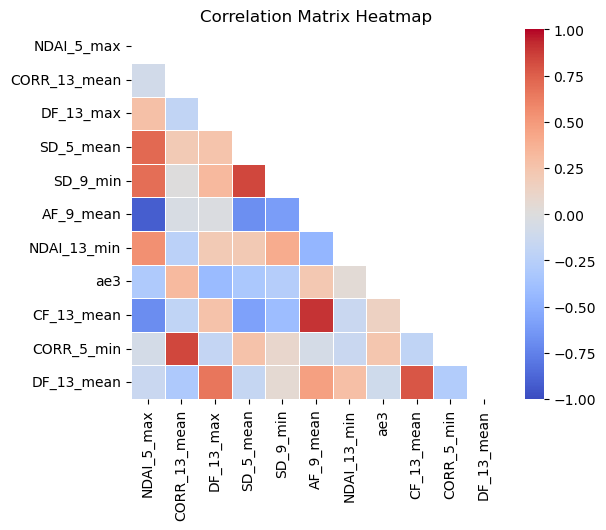

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = select_dfs.corr()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.9
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

# Drop the features
clean_data = select_dfs.drop(to_drop, axis=1)
print(f"Original shape: {select_dfs.shape}, Cleaned shape: {clean_data.shape}")

corr_matrix = clean_data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask, 
    annot=False,         # Annotate each cell with the correlation value
    cmap='coolwarm',    # Choose a color map (e.g., 'coolwarm', 'RdBu_r', etc.)
    fmt='.2f',          # Format the annotations to two decimal places
    linewidths=0.5,     # Add lines between cells
    vmin=-1,            # Set the color axis minimum value
    vmax=1,             # Set the color axis maximum value
    square=True         # Force cells to be square
)

plt.title('Correlation Matrix Heatmap') # Add a title
plt.show()

In [176]:
features_selected = clean_data.columns.to_list()

In [177]:
X_train = train_df[features_selected].values
y_train = train_df['label'].values
X_val   = val_df[features_selected].values
y_val   = val_df['label'].values
X_test  = test_df[features_selected].values
y_test  = test_df['label'].values

/scratch/users/evalynna.ong/conda/envs/env_214_test/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:30:53] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained and saved to XG_classifier_selected.joblib

── Validation Metrics ──
              precision    recall  f1-score   support

   not cloud       0.75      0.97      0.85     33528
       cloud       0.92      0.49      0.64     21244

    accuracy                           0.79     54772
   macro avg       0.84      0.73      0.74     54772
weighted avg       0.82      0.79      0.77     54772


── Test Metrics ──
              precision    recall  f1-score   support

   not cloud       0.78      1.00      0.88     50358
       cloud       0.98      0.32      0.49     20468

    accuracy                           0.80     70826
   macro avg       0.88      0.66      0.68     70826
weighted avg       0.84      0.80      0.77     70826


Feature Importances:
     feature  importance
  NDAI_5_max    0.902583
CORR_13_mean    0.065907
   DF_13_max    0.009703
    SD_9_min    0.004790
   SD_5_mean    0.003378
  CF_13_mean    0.003316
         ae3    0.003218
   AF_9_mean    0.002

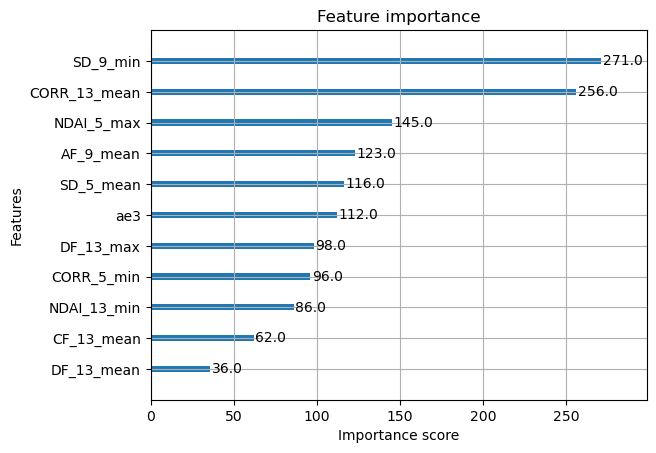

In [178]:
MODEL_FILE = 'XG_classifier_selected.joblib'
xg.xgboost_train(X_train, y_train, model_path=MODEL_FILE, random_state=42)

if os.path.exists(MODEL_FILE):
    import joblib
    clf = joblib.load(MODEL_FILE)
    
   
    results = xg.xgboost_evaluate(
        clf=clf,
        X_val=X_val, y_val=y_val, 
        X_test=X_test, y_test=y_test,
        train_df=train_df, val_df=val_df, test_df=test_df,
        FEATURE_COLS=features_selected, 
        bar=True, 
        top_ft=3
    )


In [179]:
results['top_features']

['NDAI_5_max', 'CORR_13_mean', 'DF_13_max']

Create predictions: 

Model loaded from XG_classifier_selected.joblib
ROC AUC Score: 0.946


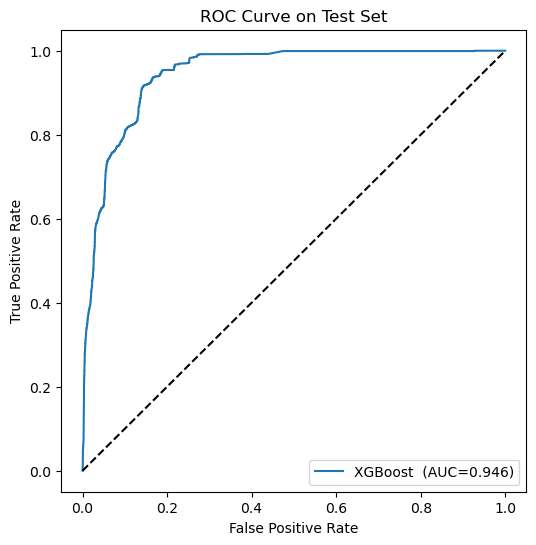

In [180]:
y_pred = xg.xgboost_predict(X_val, MODEL_FILE)
y_pred_proba = clf.predict_proba(X_val)[:, 1]

y_pred.shape

auc_score = roc_auc_score(y_val, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.3f}")

# AUC-ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost  (AUC={auc_score:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

Model loaded from XG_classifier_selected.joblib
ROC AUC Score: 0.983


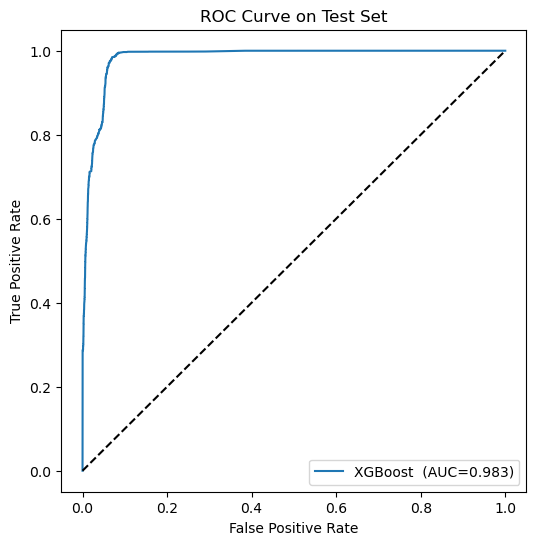

In [181]:
y_pred = xg.xgboost_predict(X_test, MODEL_FILE)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

y_pred.shape

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.3f}")

# AUC-ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost  (AUC={auc_score:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

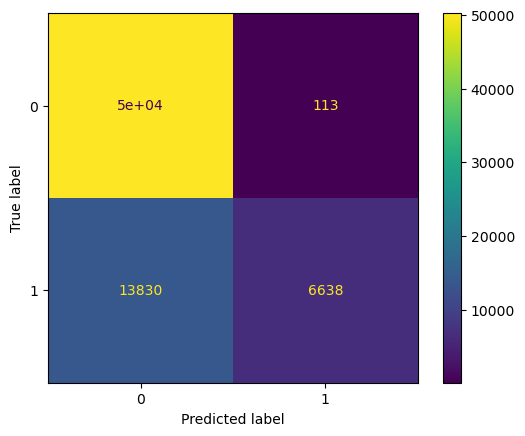


Cleaned up XG_classifier_selected.joblib


In [182]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

# cleanup
if os.path.exists(MODEL_FILE): 
    os.remove(MODEL_FILE)
    print(f"\nCleaned up {MODEL_FILE}")

High AUC; however, significant number of false negatives. That means the model is underrepresenting clouds. Perhaps the data imbalance is more significant than initially thought. 

## Error Analysis 

In [183]:
error_df = test_df[["y_coord", "x_coord", "label"]].copy()
error_df["pred_prob"] = y_pred_proba
error_df["pred_label"] = y_pred

def error_type(row):
    if row["label"] == 1 and row["pred_label"] == 1:
        return "TP"
    elif row["label"] == 0 and row["pred_label"] == 0:
        return "TN"
    elif row["label"] == 0 and row["pred_label"] == 1:
        return "FP"
    else:
        return "FN"

error_df["error_type"] = error_df.apply(error_type, axis=1)
error_df.head()

,y_coord,x_coord,label,pred_prob,pred_label,error_type
1,2.0,71.0,1,0.999788,1,TP
2,2.0,72.0,1,0.999686,1,TP
3,2.0,73.0,1,0.999587,1,TP
4,2.0,74.0,1,0.999879,1,TP
5,2.0,75.0,1,0.998935,1,TP


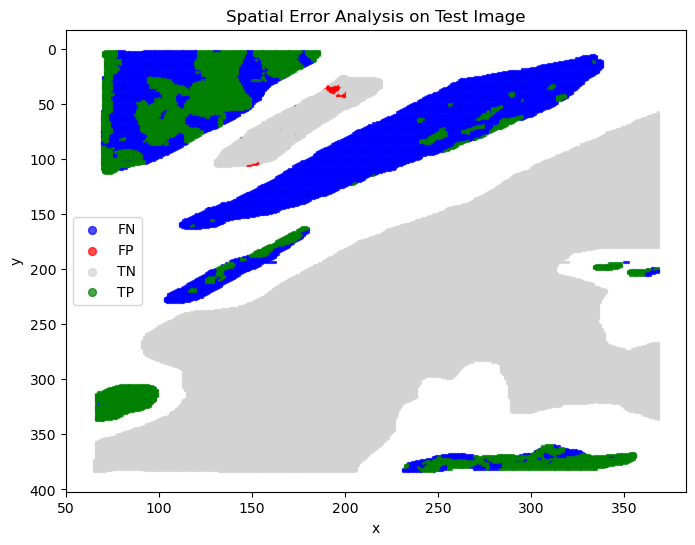

In [184]:
color_map = {"TP":"green", "TN":"lightgray", "FP":"red", "FN":"blue"}

plt.figure(figsize=(8,6))
for etype, g in error_df.groupby("error_type"):
    plt.scatter(
        g["x_coord"], g["y_coord"],
        s=2, alpha=0.7,
        label=etype,
        c=color_map[etype]
    )

plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spatial Error Analysis on Test Image")
plt.legend(markerscale=4)
plt.show()

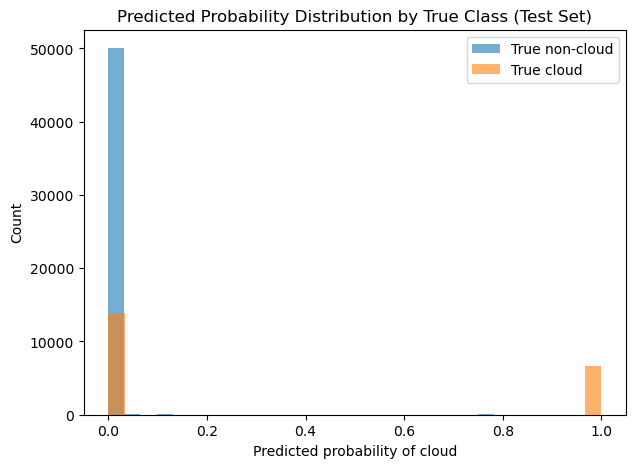

In [185]:
# probability distribution of predictions for each class
plt.figure(figsize=(7,5))
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label="True non-cloud")
plt.hist(y_pred[y_test == 1], bins=30, alpha=0.6, label="True cloud")
plt.xlabel("Predicted probability of cloud")
plt.ylabel("Count")
plt.title("Predicted Probability Distribution by True Class (Test Set)")
plt.legend()
plt.show()

## Dealing with imbalanced data

A common way to deal with imbalanced data in XGBoost is to scale the weight of the negative and positive classes. 

Still a significant number of false negatives. That is likely attributed to the imbalance of data that needs to be cleaned up. Limited to the top three features resulted in a higher false positive rate as well. A limitation of our engineered features is that more are required to provide better prediction

In [186]:
ratio = len(train_df[train_df['label']==0])/len(train_df[train_df['label']==1])

In [187]:
X_train = train_df[features_selected].values
y_train = train_df['label'].values
X_val   = val_df[features_selected].values
y_val   = val_df['label'].values
X_test  = test_df[features_selected].values
y_test  = test_df['label'].values

/scratch/users/evalynna.ong/conda/envs/env_214_test/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:31:15] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained and saved to XG_classifier.joblib

── Validation Metrics ──
              precision    recall  f1-score   support

   not cloud       0.75      0.97      0.85     33528
       cloud       0.92      0.49      0.64     21244

    accuracy                           0.79     54772
   macro avg       0.84      0.73      0.74     54772
weighted avg       0.82      0.79      0.77     54772


── Test Metrics ──
              precision    recall  f1-score   support

   not cloud       0.78      1.00      0.88     50358
       cloud       0.98      0.32      0.49     20468

    accuracy                           0.80     70826
   macro avg       0.88      0.66      0.68     70826
weighted avg       0.84      0.80      0.77     70826


Feature Importances:
     feature  importance
  NDAI_5_max    0.904068
CORR_13_mean    0.065024
   DF_13_max    0.008663
    SD_9_min    0.004796
         ae3    0.003439
   SD_5_mean    0.003320
   AF_9_mean    0.003211
  CF_13_mean    0.003203
 NDAI

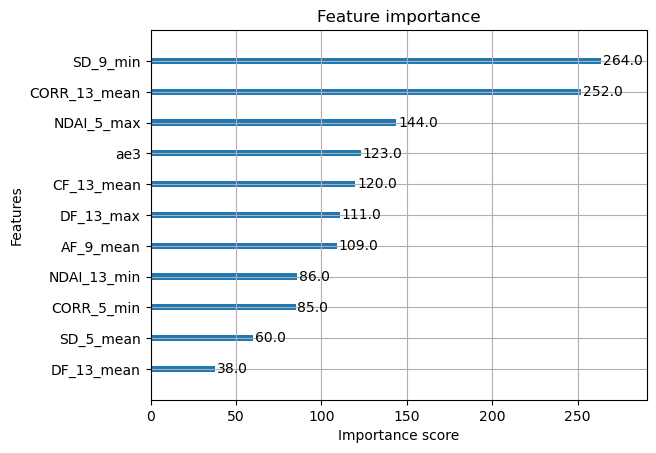

In [188]:
MODEL_FILE = 'XG_classifier.joblib'
xg.xgboost_train(X_train, y_train, model_path=MODEL_FILE, random_state=42, scale_pos_weight=ratio)

if os.path.exists(MODEL_FILE):
    import joblib
    clf = joblib.load(MODEL_FILE)
    
   
    results = xg.xgboost_evaluate(
        clf=clf,
        X_val=X_val, y_val=y_val, 
        X_test=X_test, y_test=y_test,
        train_df=train_df, val_df=val_df, test_df=test_df,
        FEATURE_COLS=features_selected,
        bar=True
    )


ROC AUC Score: 0.983


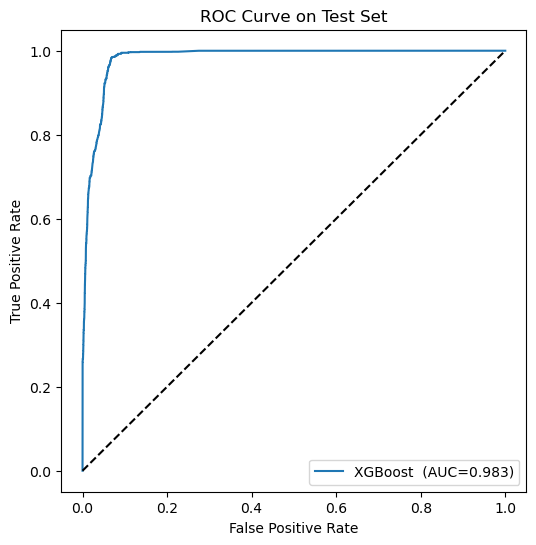

In [189]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.3f}")

# AUC-ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost  (AUC={auc_score:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

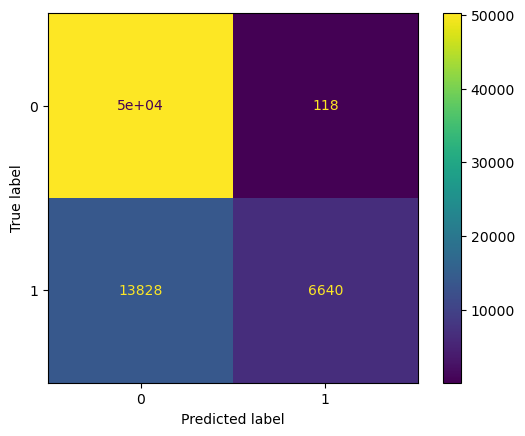


Cleaned up XG_classifier.joblib


In [190]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

if os.path.exists(MODEL_FILE): 
    os.remove(MODEL_FILE)
    print(f"\nCleaned up {MODEL_FILE}")

## What if I take just the top three features from this now

In [191]:
results['top_features']

['NDAI_5_max',
 'CORR_13_mean',
 'DF_13_max',
 'SD_9_min',
 'ae3',
 'SD_5_mean',
 'AF_9_mean',
 'CF_13_mean',
 'NDAI_13_min',
 'DF_13_mean',
 'CORR_5_min']

In [192]:
top_three = results['top_features']

In [193]:
X_train = train_df[top_three].values
y_train = train_df['label'].values
X_val   = val_df[top_three].values
y_val   = val_df['label'].values
X_test  = test_df[top_three].values
y_test  = test_df['label'].values

/scratch/users/evalynna.ong/conda/envs/env_214_test/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:31:33] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained and saved to XG_classifier.joblib

── Validation Metrics ──
              precision    recall  f1-score   support

   not cloud       0.75      0.97      0.85     33528
       cloud       0.92      0.49      0.64     21244

    accuracy                           0.79     54772
   macro avg       0.84      0.73      0.74     54772
weighted avg       0.82      0.79      0.77     54772


── Test Metrics ──
              precision    recall  f1-score   support

   not cloud       0.78      1.00      0.88     50358
       cloud       0.98      0.32      0.49     20468

    accuracy                           0.80     70826
   macro avg       0.88      0.66      0.68     70826
weighted avg       0.84      0.80      0.77     70826


Feature Importances:
     feature  importance
  NDAI_5_max    0.902582
CORR_13_mean    0.065906
   DF_13_max    0.009703
    SD_9_min    0.004793
   SD_5_mean    0.003377
  CF_13_mean    0.003316
         ae3    0.003218
   AF_9_mean    0.002917
 NDAI

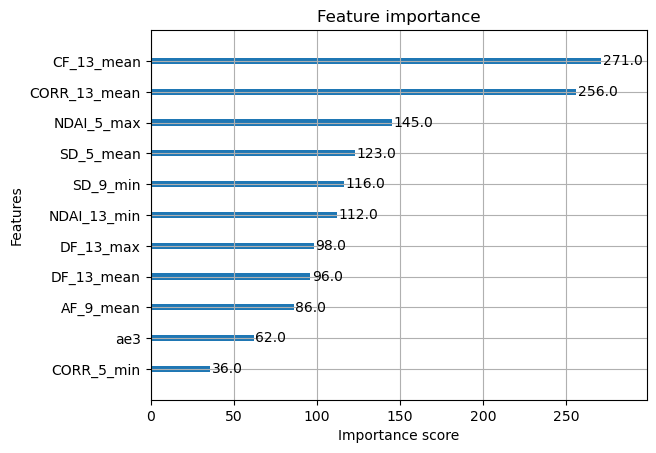

In [194]:
MODEL_FILE = 'XG_classifier.joblib'
xg.xgboost_train(X_train, y_train, model_path=MODEL_FILE, random_state=42)

if os.path.exists(MODEL_FILE):
    import joblib
    clf = joblib.load(MODEL_FILE)
    
   
    results = xg.xgboost_evaluate(
        clf=clf,
        X_val=X_val, y_val=y_val, 
        X_test=X_test, y_test=y_test,
        train_df=train_df, val_df=val_df, test_df=test_df,
        FEATURE_COLS=top_three, 
        bar=True
    )


ROC AUC Score: 0.983


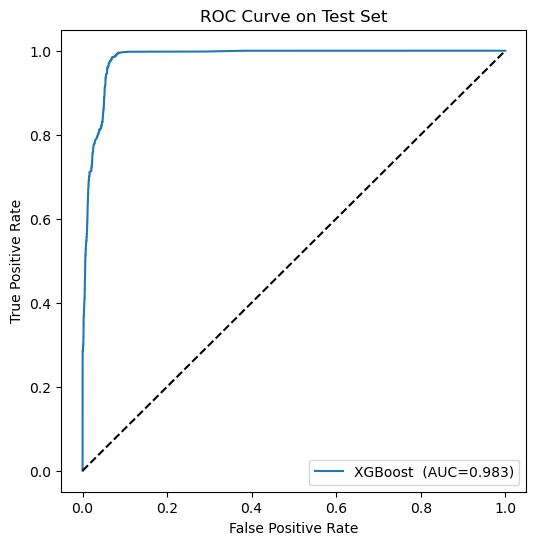

In [195]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.3f}")

# AUC-ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost  (AUC={auc_score:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

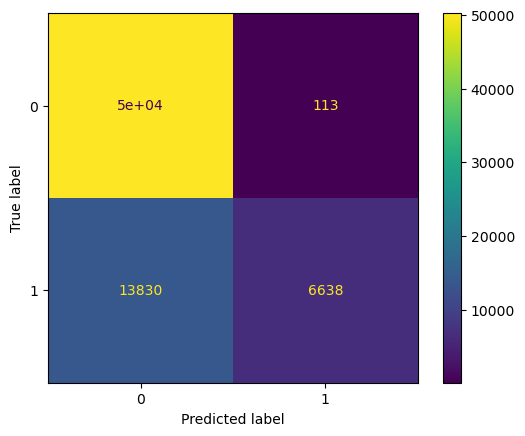


Cleaned up XG_classifier.joblib


In [196]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

if os.path.exists(MODEL_FILE): 
    os.remove(MODEL_FILE)
    print(f"\nCleaned up {MODEL_FILE}")

## Compare with features engineered in paper

In [197]:
features = ['NDAI', 'SD', 'CORR']

In [198]:
X_train = train_df[features].values
y_train = train_df['label'].values
X_val   = val_df[features].values
y_val   = val_df['label'].values
X_test  = test_df[features].values
y_test  = test_df['label'].values

/scratch/users/evalynna.ong/conda/envs/env_214_test/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:31:51] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained and saved to XG_classifier.joblib

── Validation Metrics ──
              precision    recall  f1-score   support

   not cloud       0.74      0.95      0.83     33528
       cloud       0.86      0.48      0.62     21244

    accuracy                           0.77     54772
   macro avg       0.80      0.72      0.72     54772
weighted avg       0.79      0.77      0.75     54772


── Test Metrics ──
              precision    recall  f1-score   support

   not cloud       0.82      0.98      0.89     50358
       cloud       0.91      0.46      0.61     20468

    accuracy                           0.83     70826
   macro avg       0.86      0.72      0.75     70826
weighted avg       0.84      0.83      0.81     70826


Feature Importances:
feature  importance
   NDAI    0.792183
   CORR    0.113966
     SD    0.093851


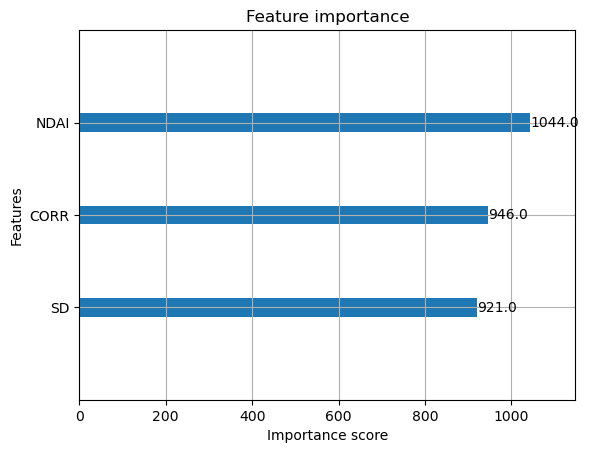

In [199]:
MODEL_FILE = 'XG_classifier.joblib'
xg.xgboost_train(X_train, y_train, model_path=MODEL_FILE, random_state=42)

if os.path.exists(MODEL_FILE):
    import joblib
    clf = joblib.load(MODEL_FILE)
    
   
    results = xg.xgboost_evaluate(
        clf=clf,
        X_val=X_val, y_val=y_val, 
        X_test=X_test, y_test=y_test,
        train_df=train_df, val_df=val_df, test_df=test_df,
        FEATURE_COLS=features, 
        bar=True
    )


ROC AUC Score: 0.973


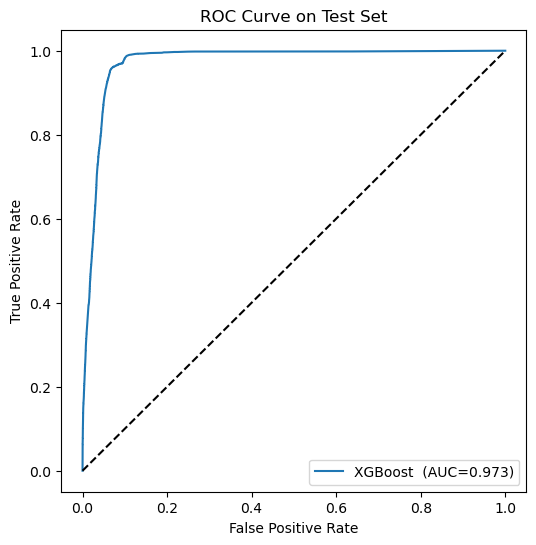

In [200]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.3f}")

# AUC-ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost  (AUC={auc_score:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

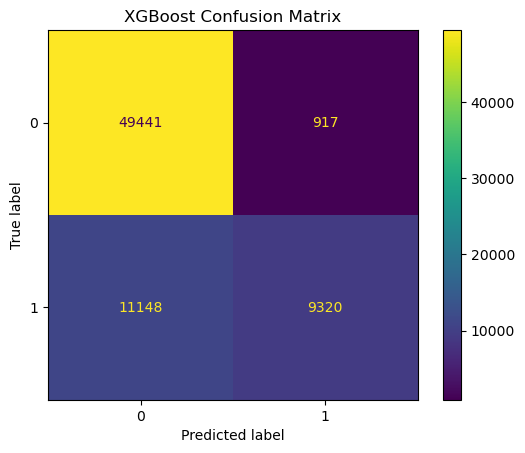


Cleaned up XG_classifier.joblib


In [201]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

if os.path.exists(MODEL_FILE): 
    os.remove(MODEL_FILE)
    print(f"\nCleaned up {MODEL_FILE}")

In [202]:
error_df = test_df[["y_coord", "x_coord", "label"]].copy()
error_df["pred_prob"] = y_pred_proba
error_df["pred_label"] = y_pred

def error_type(row):
    if row["label"] == 1 and row["pred_label"] == 1:
        return "TP"
    elif row["label"] == 0 and row["pred_label"] == 0:
        return "TN"
    elif row["label"] == 0 and row["pred_label"] == 1:
        return "FP"
    else:
        return "FN"

error_df["error_type"] = error_df.apply(error_type, axis=1)
error_df.head()

,y_coord,x_coord,label,pred_prob,pred_label,error_type
1,2.0,71.0,1,0.998525,1,TP
2,2.0,72.0,1,0.975119,1,TP
3,2.0,73.0,1,0.967430,1,TP
4,2.0,74.0,1,0.994524,1,TP
5,2.0,75.0,1,0.994951,1,TP


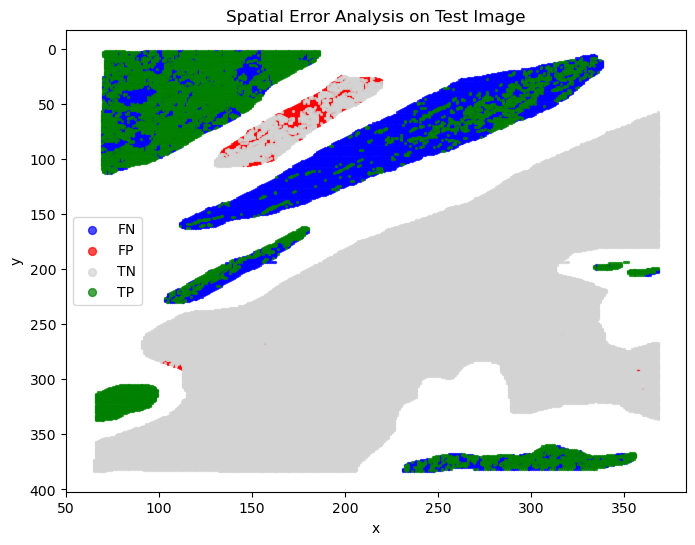

In [203]:
color_map = {"TP":"green", "TN":"lightgray", "FP":"red", "FN":"blue"}

plt.figure(figsize=(8,6))
for etype, g in error_df.groupby("error_type"):
    plt.scatter(
        g["x_coord"], g["y_coord"],
        s=2, alpha=0.7,
        label=etype,
        c=color_map[etype]
    )

plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spatial Error Analysis on Test Image")
plt.legend(markerscale=4)
plt.show()

## Attempt with just the autoencodings: 

In [204]:
features = ['ae0', 'ae1', 'ae2', 'ae3', 'ae4', 'ae5', 'ae6', 'ae7']

In [205]:
X_train = train_df[features].values
y_train = train_df['label'].values
X_val   = val_df[features].values
y_val   = val_df['label'].values
X_test  = test_df[features].values
y_test  = test_df['label'].values

/scratch/users/evalynna.ong/conda/envs/env_214_test/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:32:12] WARNING: /home/task_177203090464722/croot/xgboost-split_1772031726713/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained and saved to XG_classifier.joblib

── Validation Metrics ──
              precision    recall  f1-score   support

   not cloud       0.74      0.98      0.85     33528
       cloud       0.95      0.46      0.62     21244

    accuracy                           0.78     54772
   macro avg       0.85      0.72      0.74     54772
weighted avg       0.82      0.78      0.76     54772


── Test Metrics ──
              precision    recall  f1-score   support

   not cloud       0.77      0.99      0.86     50358
       cloud       0.89      0.27      0.41     20468

    accuracy                           0.78     70826
   macro avg       0.83      0.63      0.64     70826
weighted avg       0.80      0.78      0.73     70826


Feature Importances:
feature  importance
    ae0    0.836178
    ae3    0.107955
    ae6    0.015722
    ae1    0.013418
    ae5    0.011126
    ae4    0.005585
    ae2    0.005172
    ae7    0.004844


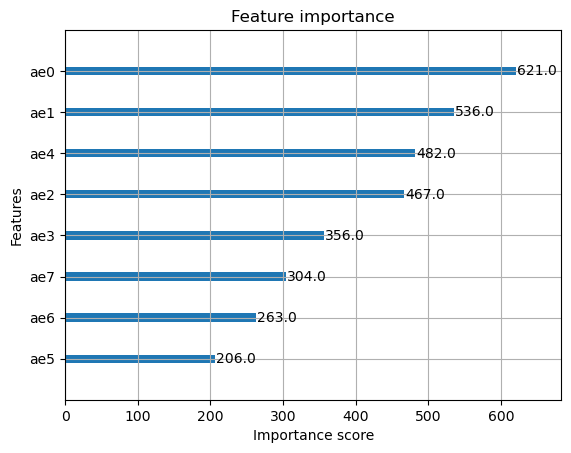

In [206]:
MODEL_FILE = 'XG_classifier.joblib'
xg.xgboost_train(X_train, y_train, model_path=MODEL_FILE, random_state=42)

if os.path.exists(MODEL_FILE):
    import joblib
    clf = joblib.load(MODEL_FILE)
    
   
    results = xg.xgboost_evaluate(
        clf=clf,
        X_val=X_val, y_val=y_val, 
        X_test=X_test, y_test=y_test,
        train_df=train_df, val_df=val_df, test_df=test_df,
        FEATURE_COLS=features, 
        bar=True
    )


In [207]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

In [208]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.3f}")

ROC AUC Score: 0.947


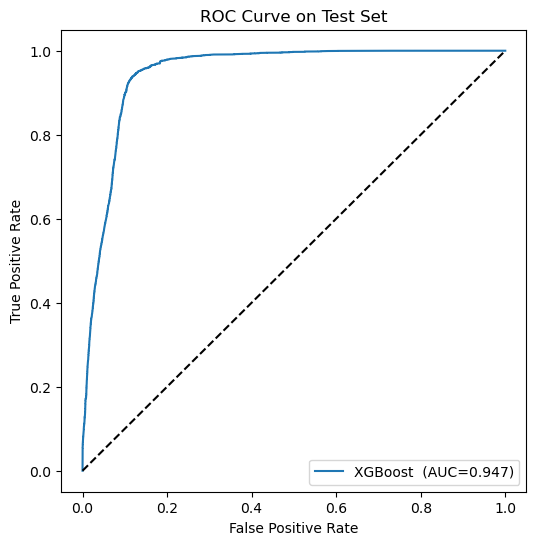

In [209]:
# AUC-ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost  (AUC={auc_score:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

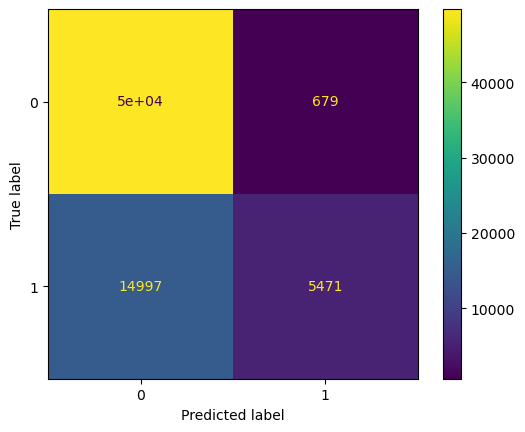


Cleaned up XG_classifier.joblib


In [210]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

if os.path.exists(MODEL_FILE): 
    os.remove(MODEL_FILE)
    print(f"\nCleaned up {MODEL_FILE}")